# ARTI404 – Image Processing
## Lab 4: Intensity Transformations and Filtering – Spatial Domain

**Student:** Mohammed Moayed Alquriniy  
**ID:** 2240007325

# Part 1: Procedural Steps
## Task #1: Thresholding
### Step #1: Apply thresholding with a fixed threshold on an image
Each pixel above the threshold becomes white (255) and every other pixel becomes black (0).
> Note: the results are displayed with Matplotlib instead of `cv2.imshow`, so that they appear inside the notebook.

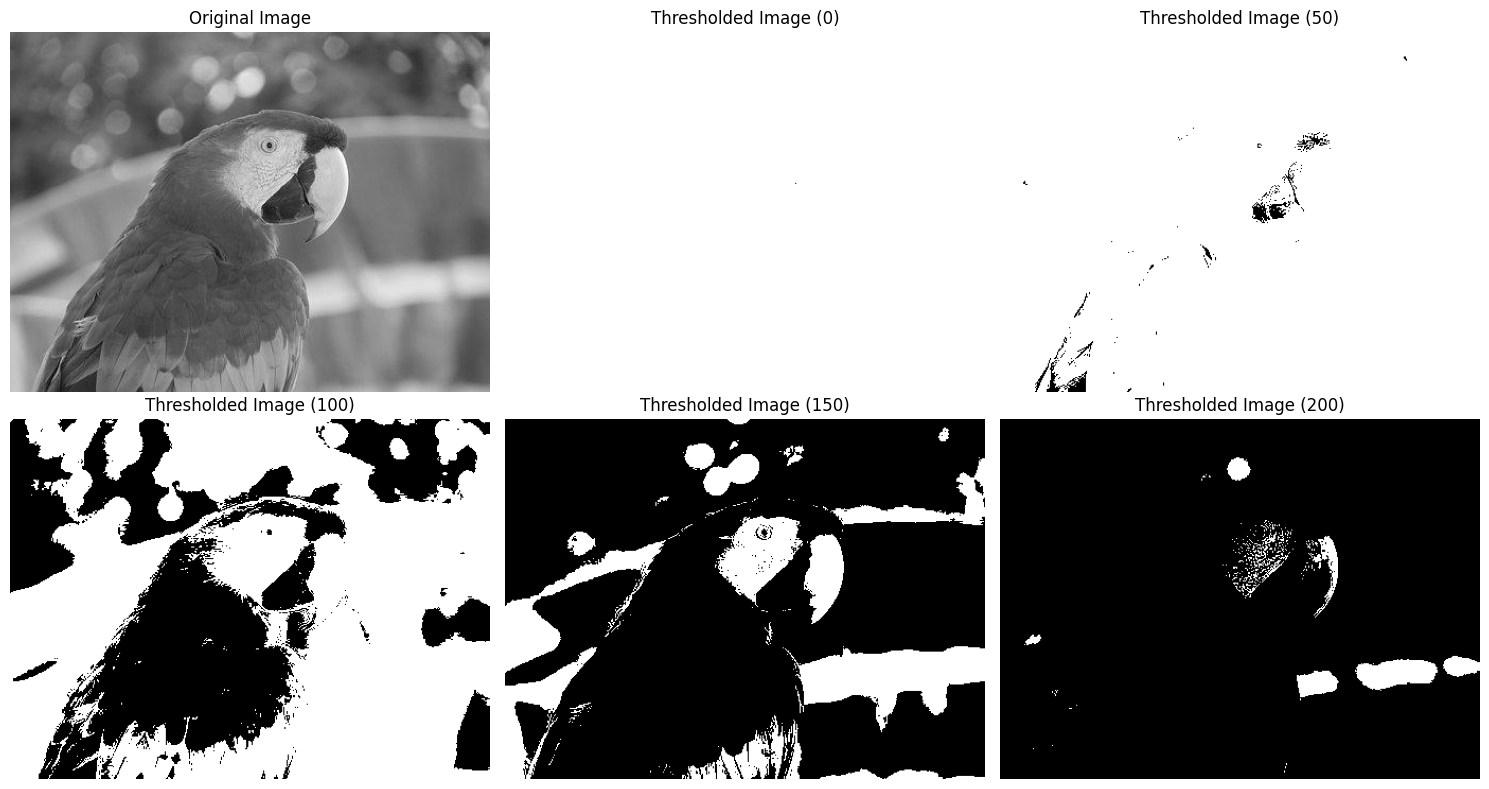

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('../images/Parrot.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Display the original image
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    axes[i + 1].imshow(thresh, cmap='gray')
    axes[i + 1].set_title(f'Thresholded Image ({threshold_value})')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

**Observation:** With threshold 0 almost the whole image is white. As the threshold increases, fewer pixels pass it, so the image becomes darker and only the brightest parts (the white face, the beak and some bright spots in the background) stay white at 200.

## Task #2: Histogram Processing
### Step #1: Load necessary libraries

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

### Step #2: Load moon image

In [3]:
img = data.moon()

### Step #3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles

In [4]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

### Step #4: Display the image with its histogram of (Step #2) and (Step #3)

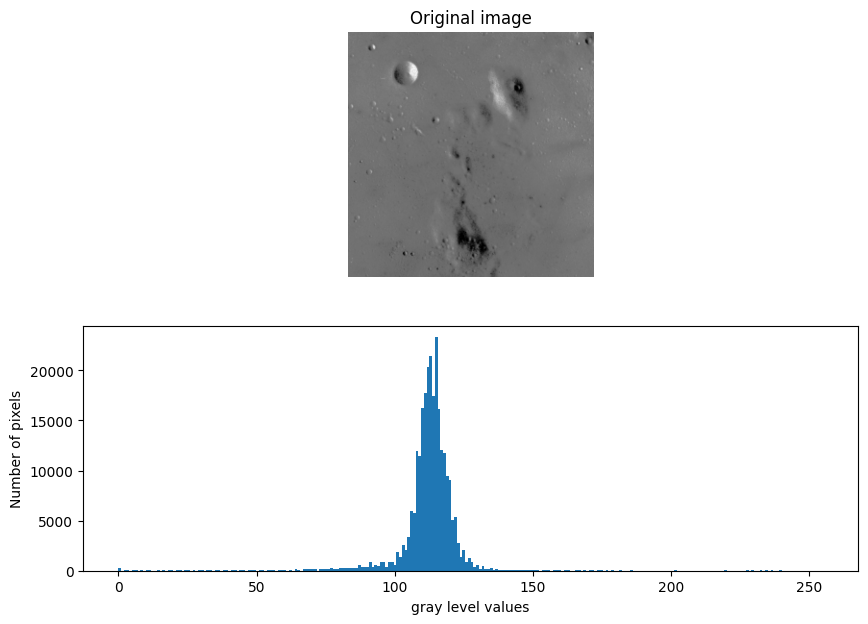

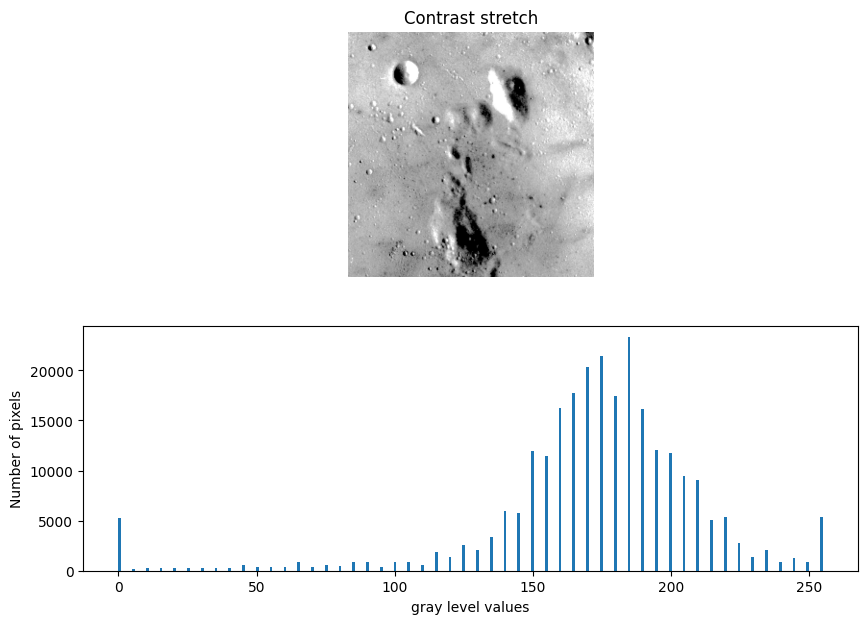

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Part 2: Assessment
## Task #1: Contrast stretching between the 3rd and 80th percentiles
Using the same moon image, the intensities between the 3rd and 80th percentiles are stretched to the full range [0, 255].
Values below the 3rd percentile become 0 and values above the 80th percentile become 255.

3rd percentile  = 87.0
80th percentile = 118.0


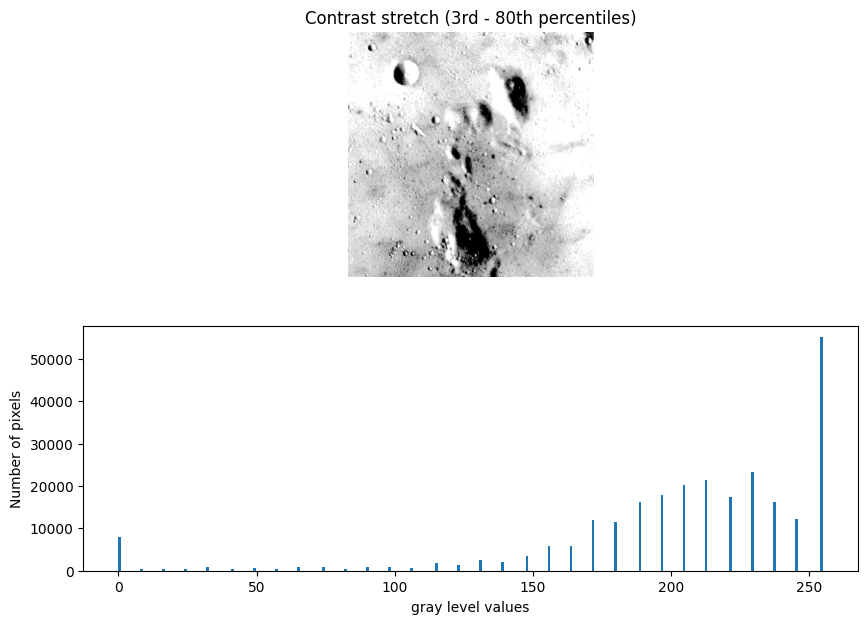

In [6]:
# Contrast stretching (3rd - 80th percentiles)
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))

print('3rd percentile  =', p3)
print('80th percentile =', p80)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch (3rd - 80th percentiles)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observation:** Because the upper limit is the 80th percentile (instead of the 98th), about 20% of the pixels are pushed to 255. 
The image becomes brighter with higher contrast, and the histogram shows a tall spike at 255 (saturation). 
The gaps between the bars appear because the small input range (87 to 118) is stretched over 0 to 255.

## Task #2: Histogram Equalization
Using the same moon image and `exposure.equalize_hist`, the histogram is flattened (spread almost evenly over all gray levels).
> Note: `equalize_hist` returns a **float** image with values in [0, 1], so the histogram range is (0, 1).

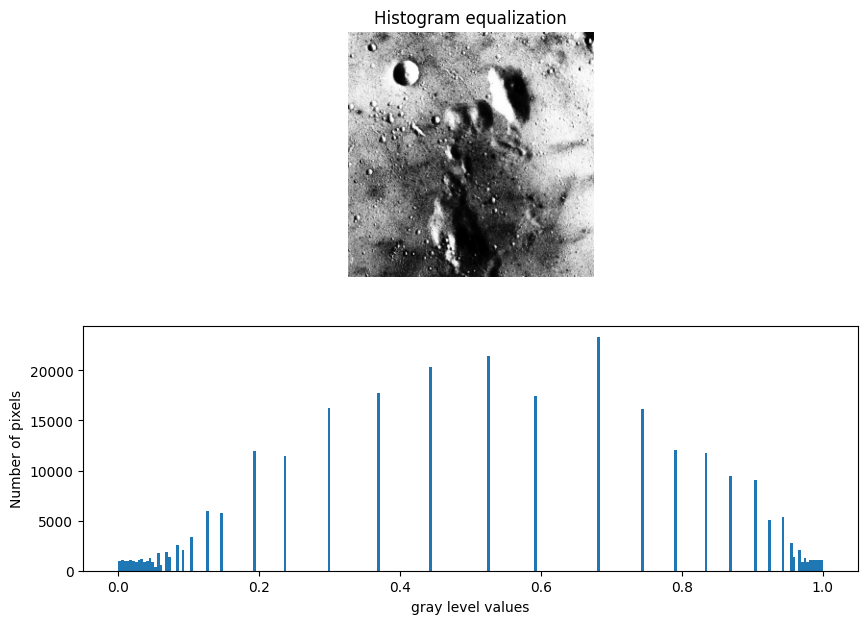

In [7]:
# Histogram equalization
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap = 'gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins = 256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observation:** The equalized histogram is spread over the whole intensity range, so hidden details in the dark and bright areas of the moon become visible.

## Task #3: Histogram Matching
The Chelsea image is the **source** image and the rocket image is the **reference**. 
`exposure.match_histograms` changes the source so that its histogram (for each R, G, B channel) matches the reference histogram.

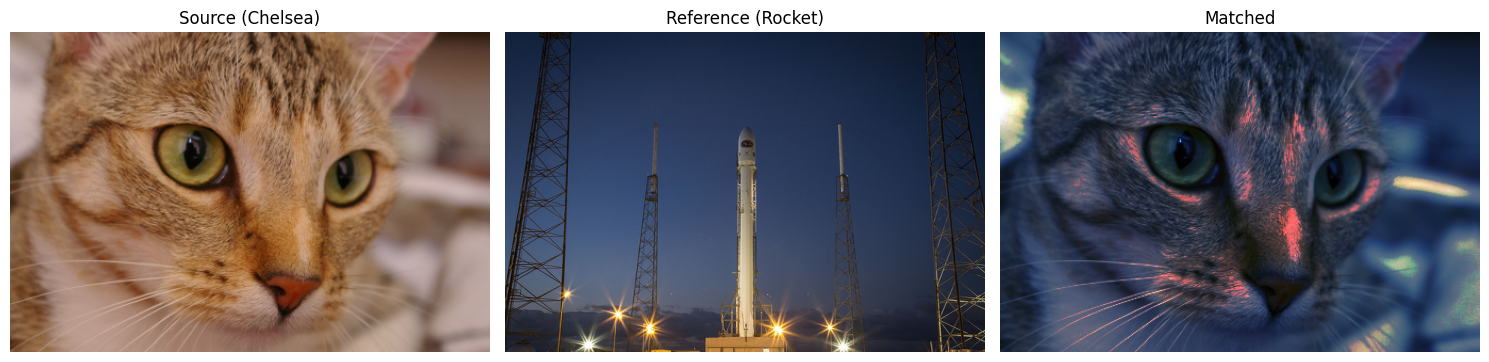

In [8]:
reference = data.rocket()
image = data.chelsea()

matched = exposure.match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title('Source (Chelsea)')
axes[1].imshow(reference)
axes[1].set_title('Reference (Rocket)')
axes[2].imshow(matched.astype(np.uint8))
axes[2].set_title('Matched')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Histograms and cumulative histograms of each channel (R, G, B)

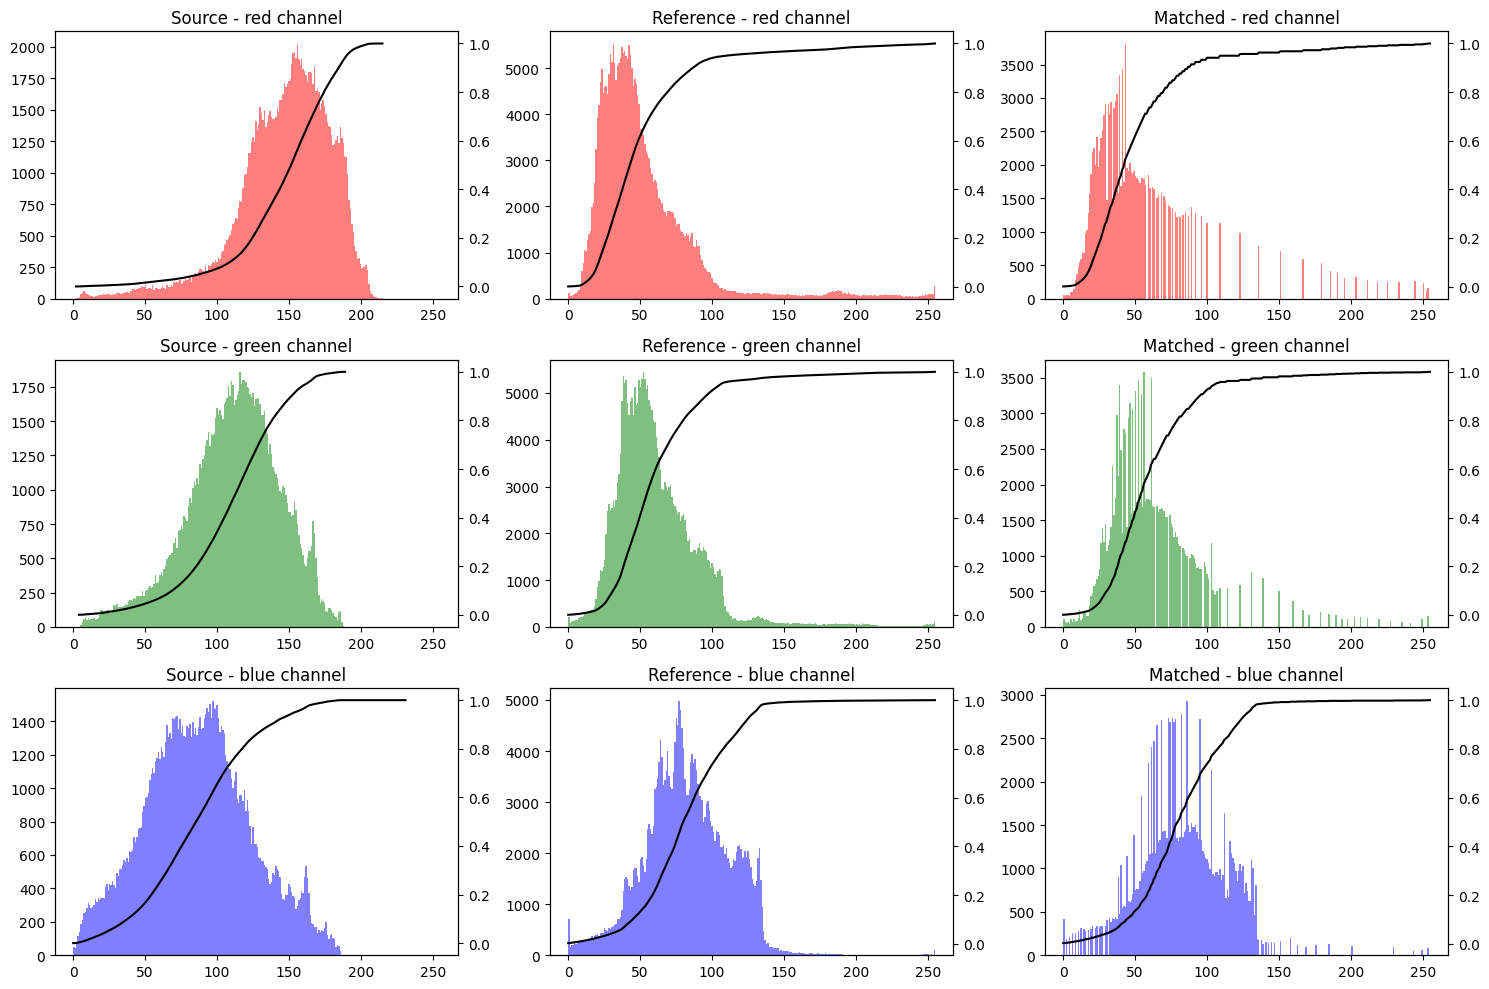

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
colors = ['red', 'green', 'blue']

for i, c in enumerate(colors):
    for j, (im, name) in enumerate([(image, 'Source'), (reference, 'Reference'), (matched, 'Matched')]):
        channel = im[..., i].astype(np.uint8)
        axes[i, j].hist(channel.flat, bins=256, range=(0, 255), color=c, alpha=0.5)
        ax_cdf = axes[i, j].twinx()
        cdf, bins = exposure.cumulative_distribution(channel, 256)
        ax_cdf.plot(bins, cdf, 'k')
        axes[i, j].set_title(f'{name} - {c} channel')

plt.tight_layout()
plt.show()

**Observation:** After matching, the cumulative histogram of every channel in the matched image has the same shape as the reference (rocket) image. 
So the Chelsea image keeps its content (the cat) but takes the colors and brightness distribution of the rocket image.